# D16 · Make analytical choices visible before publication

Different reasonable analysis choices can produce different estimates from the same dataset. A multiverse or specification analysis makes a defined set of choices visible rather than silently choosing the result that supports a preferred story. It does not mean trying every possible pipeline, nor does agreement among many similar analyses prove validity. All pipelines may share the same confound or measurement error.

Choices can change the estimand. An unadjusted group contrast and a contrast adjusted for site are not interchangeable versions of the same arithmetic. Excluding high-motion participants changes the analyzed population. Using a median rather than a mean changes the summary target. A useful specification table records the scientific rationale and interpretation of each branch, not only its p value. Invalid analyses can be included as explicitly labeled failure demonstrations, but should not be counted as equally defensible evidence.

The synthetic study below has partially imbalanced sites, an additive group effect, measurement noise, and motion values. We compare a small prespecified family: adjusted versus unadjusted, and two QC rules. The point is to audit the consequences and retained groups, not to identify the most significant branch. The generator exposes the known causal mechanism for teaching; real studies require substantive reasoning about whether a covariate is a confound, mediator, or collider before adjustment.

A preregistration freezes the scientific question, preprocessing and modelling decisions, exclusions, contrast, family of tests, and stopping rule before the relevant outcomes influence them. Exploratory analyses remain valuable when labeled and followed by independent evidence. A reproducibility record adds the exact inputs, code, environment, parameters, executed outputs, and decision history. Computational reproducibility means another execution can reconstruct a result; replication uses independent evidence to examine whether the scientific conclusion persists. A deterministic wrong analysis can be perfectly reproducible.

Here a JSON representation captures the planned branch family and a SHA-256 digest fingerprints the synthetic inputs. A digest detects byte changes; it does not verify measurement accuracy, prove ethical collection, or establish scientific validity. Software version and model/tutor provenance help reconstruct how code was produced, but the executed code and scientific rationale remain essential.

Run every listed branch and report retained participants. Do not rank branches by how persuasive their p values look.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib,json,sys
rng=np.random.default_rng(216);n=120
group=np.repeat([0.,1.],n//2)
site=np.r_[np.tile([0.,0.,1.],20),np.tile([0.,1.,1.],20)]
motion=rng.uniform(0,1,n)
y=.4*group+1.5*site+rng.normal(0,.5,n)
results=[]
for cutoff in [1.,.8]:
    keep=motion<=cutoff
    for adjust in [False,True]:
        cols=[np.ones(keep.sum()),group[keep]]
        if adjust: cols.append(site[keep])
        X=np.column_stack(cols);b=np.linalg.lstsq(X,y[keep],rcond=None)[0]
        results.append({'qc_cutoff':cutoff,'adjust_site':adjust,'n':keep.sum(),'group_effect':b[1]})
table=pd.DataFrame(results);assert len(table)==4
print(table.to_string(index=False))

 qc_cutoff  adjust_site   n  group_effect
       1.0        False 120      0.986690
       1.0         True 120      0.453179
       0.8        False  98      0.991902
       0.8         True  98      0.473472


Preserve the specification before interpretation. Changing a decision leaves a different record.

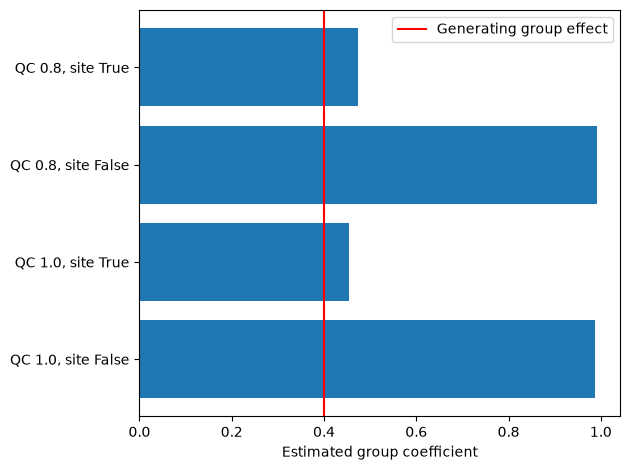

{
  "plan": {
    "estimand": "group contrast conditional on declared covariates",
    "primary": "site-adjusted, cutoff 1.0",
    "branches": [
      1.0,
      0.8
    ],
    "seed": 216,
    "stopping": "fixed n=120"
  },
  "input_sha256": "4dda2d829324eff1c3d6be35e28a95325d3a3ea7673b77d090beb6d8ef6616c2",
  "python": "3.14.7",
  "numpy": "2.5.3"
}


In [2]:
plan={'estimand':'group contrast conditional on declared covariates','primary':'site-adjusted, cutoff 1.0','branches':[1.0,.8],'seed':216,'stopping':'fixed n=120'}
frozen=json.dumps(plan,sort_keys=True)
input_hash=hashlib.sha256(np.column_stack([group,site,motion,y]).tobytes()).hexdigest()
record={'plan':plan,'input_sha256':input_hash,'python':sys.version.split()[0],'numpy':np.__version__}
assert json.dumps(plan,sort_keys=True)==frozen
changed=dict(plan,primary='smallest p value')
assert json.dumps(changed,sort_keys=True)!=frozen
assert len(input_hash)==64
plt.barh(np.arange(4),table.group_effect)
plt.yticks(np.arange(4),[f'QC {r.qc_cutoff}, site {r.adjust_site}' for r in table.itertuples()])
plt.axvline(.4,color='red',label='Generating group effect')
plt.xlabel('Estimated group coefficient');plt.legend();plt.tight_layout();plt.show()
print(json.dumps(record,indent=2))

## Supervise the AI, then transfer the idea

**AI prompt:** “List each branch's estimand, retained sample, and assumptions before interpreting its estimate. Explain why the unadjusted and adjusted effects differ. Help me draft a preregistration and a transparent deviations log; do not hide branches or choose the primary analysis after seeing outcomes.”

**Deliberate mistake:** rewrite the primary analysis field to whichever branch looks strongest and retain the original timestamp. Explain why that misrepresents prospective planning. Repair with an honest dated amendment and explicit exploratory labeling. Transfer by versioning code, preserving raw data, using an analysis manifest, recording package/model versions, and testing the whole workflow on an appropriately licensed public dataset. Deliver a primary analysis plan, a justified sensitivity family, a deviations table, and a replication proposal that would provide new evidence rather than merely rerun the same code.

## Answer key — read after your own explanation

Site imbalance contributes to the unadjusted contrast; including site targets a different conditional comparison under the specified additive model. QC thresholds change the retained sample, even when the cutoff was not chosen using y. A JSON record and input digest make changes detectable but do not certify scientific correctness. Multiverse branches need rationale; counting significant branches is not automatically a calibrated inference procedure. Preregistration and independent replication address different weaknesses.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [Berkeley projects and reproducible GitHub submission](https://bic-berkeley.github.io/psych-214-fall-2016/projects.html); [Botvinik-Nezer et al., many-team neuroimaging analysis study](https://www.nature.com/articles/s41586-020-2314-9); [Center for Open Science preregistration](https://www.cos.io/initiatives/prereg). See [the coverage and gaps](../../curriculum/design_coverage.md).